# Potential-averaged Delta-SCF methods: underlying formalism and evaluation of accuracy of excitation energies
**Author**: Egor Trushin  
**Date created**: 11/04/2026  
**Last modified**: 20/04/2026

## 1. Data processing

In [1]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
XC = ["LDA", "PBE", "r2SCAN", "PBE0", "r2SCAN0", "HSE12"]
INDEX = ["LDA", "PBE", "r$^2$SCAN", "PBE0", "r$^2$SCAN0", "HSE12"]
COLUMNS = ["UKS", "pa-SS-KS", "pa-OSS-KS", "pa-STA-KS"]
COLUMNS_OEP = ["UKS-OEP", "SS-KS-OEP", "OSS-KS-OEP", "STA-KS-OEP"]
LATEX_TABLES = True

In [3]:
os.makedirs("csv", exist_ok=True)

### 1.1 Convergence check

In [4]:
def parse_output(path: Path) -> list[dict]:
    """Return a list of convergence failures found in an output file.

    Each failure is a dict with keys 'system' and 'calc'.
    """
    # Matches system header lines like "[3/16] Acetaldehyde" or "[15/27] N-Phenylpyrrole B2"
    system_re = re.compile(r"^\[\d+/\d+\] (.+)$")
    # Standard KS: "<method> excited-state ... did not converge"
    ks_fail_re = re.compile(r"^(.+) did not converge$")
    # OEP: "Running <description>" followed by "SCF was not converged"
    oep_running_re = re.compile(r"^Running (.+)$")
    oep_fail = "SCF was not converged"

    is_oep = "oep" in path.parts[-3]  # dataset folder name contains "oep"
    failures = []
    current_system = None
    last_running = None

    for line in path.read_text(errors="replace").splitlines():
        line = line.strip()

        m = system_re.match(line)
        if m:
            current_system = m.group(1)
            last_running = None
            continue

        if is_oep:
            m = oep_running_re.match(line)
            if m:
                last_running = m.group(1)
                continue
            if line == oep_fail and current_system is not None:
                calc = last_running if last_running else "unknown"
                failures.append({"system": current_system, "calc": calc})
                last_running = None
        else:
            m = ks_fail_re.match(line)
            if m and current_system is not None:
                failures.append({"system": current_system, "calc": m.group(1)})

    return failures

In [5]:
def check_convergence(results_dir: Path = None):
    """Scan all output files under results_dir and print unconverged calculations."""
    if results_dir is None:
        try:
            results_dir = Path(__file__).parent / "results"
        except NameError:
            results_dir = Path("results")
    all_failures = {}  # (dataset, xc) -> list of failure dicts

    for output_file in sorted(results_dir.glob("*/*/output")):
        xc = output_file.parent.name
        dataset = output_file.parent.parent.name
        failures = parse_output(output_file)
        if failures:
            all_failures[(dataset, xc)] = failures

    if not all_failures:
        print("No unconverged calculations found.")
    else:
        print("UNCONVERGED CALCULATIONS")

        for (dataset, xc), failures in all_failures.items():
            print(f"\n{dataset} / {xc}  ({len(failures)} failure{'s' if len(failures) != 1 else ''})")
            for f in failures:
                print(f"  {f['system']:<35}  {f['calc']}")

In [6]:
check_convergence()

UNCONVERGED CALCULATIONS

quest6 / HSE12  (3 failures)
  Dimethylaniline A1                   UKS excited-state singlet calculation
  N-Phenylpyrrole A1                   UKS excited-state triplet calculation
  Twisted PP B1                        UKS excited-state singlet calculation

quest6 / LDA  (4 failures)
  N-Phenylpyrrole B2                   pa-SS-KS excited-state singlet calculation
  N-Phenylpyrrole B2                   pa-SS-KS excited-state triplet calculation
  N-Phenylpyrrole B2                   pa-OSS-KS excited-state calculation
  N-Phenylpyrrole B2                   pa-STA-KS excited-state calculation

quest6 / PBE  (3 failures)
  N-Phenylpyrrole B2                   pa-SS-KS excited-state singlet calculation
  N-Phenylpyrrole B2                   pa-SS-KS excited-state triplet calculation
  N-Phenylpyrrole B2                   pa-OSS-KS excited-state calculation

quest6 / PBE0  (3 failures)
  N-Phenylpyrrole A1                   UKS excited-state triplet calculation

### 1.2 Parsing excitations

#### 1.2.1 QUEST1 lowest OEP

In [7]:
for xc in XC:
    with open(f"results/quest1_lowest_oep/{xc}/results.json") as json_data:
        data = json.load(json_data)
    df = pd.DataFrame.from_dict(data, orient="index")
    df = df.iloc[:, [0, 3, 5, 7, 9, 1, 4, 6, 8, 10, 2]]
    df["UKS-OEP ST"] = df["UKS-OEP S"].values - df["UKS-OEP T"].values
    df["SS-KS-OEP ST"] = df["SS-KS-OEP S"].values - df["SS-KS-OEP T"].values
    df["OSS-KS-OEP ST"] = df["OSS-KS-OEP S"].values - df["OSS-KS-OEP T"].values
    df["STA-KS-OEP ST"] = df["STA-KS-OEP S"].values - df["STA-KS-OEP T"].values
    df["TBE ST"] = df["TBE S"].values - df["TBE T"].values
    df.to_csv(f"csv/QUEST1_lowest_{xc}_OEP.csv")

print("Number of excitations", len(df))

Number of excitations 16


#### 1.2.2 QUEST1 lowest

In [8]:
for xc in XC:
    with open(f"results/quest1_lowest/{xc}/results.json") as json_data:
        data = json.load(json_data)
    df = pd.DataFrame.from_dict(data, orient="index")
    df = df.iloc[:, [0, 3, 5, 7, 9, 1, 4, 6, 8, 10, 2]]
    df["UKS ST"] = df["UKS S"].values - df["UKS T"].values
    df["pa-SS-KS ST"] = df["pa-SS-KS S"].values - df["pa-SS-KS T"].values
    df["pa-OSS-KS ST"] = df["pa-OSS-KS S"].values - df["pa-OSS-KS T"].values
    df["pa-STA-KS ST"] = df["pa-STA-KS S"].values - df["pa-STA-KS T"].values
    df.to_csv(f"csv/QUEST1_lowest_{xc}.csv")

print("Number of excitations", len(df))

Number of excitations 16


#### 1.2.3 QUEST1 higher

In [9]:
for xc in XC:
    with open(f"results/quest1_higher/{xc}/results.json") as json_data:
        data = json.load(json_data)

    new_dict = {}
    for s in data:
        for exci in data[s]:
            new_dict[s + " " + exci] = data[s][exci]

    df = pd.DataFrame.from_dict(new_dict, orient="index")
    df = df.iloc[:, [0, 3, 5, 7, 9, 1, 4, 6, 8, 10, 2]]
    df.index = df.index.map(lambda x: " ".join(x.split()[:-1]))
    df.to_csv(f"csv/QUEST1_higher_{xc}.csv")

print("Number of excitations", len(df))

Number of excitations 17


#### 1.2.4 QUEST6

In [10]:
for xc in XC:
    with open(f"results/quest6/{xc}/results.json") as json_data:
        data = json.load(json_data)

    new_dict = {}
    for s in data:
        for exci in data[s]:
            new_dict[s + " " + exci] = data[s][exci]

    df = pd.DataFrame.from_dict(new_dict, orient="index")
    df = df.drop(df[df.index == "N-Phenylpyrrole A1"].index)
    df = df.drop(df[df.index == "N-Phenylpyrrole B2"].index)
    df = df.drop(df[df.index == "Twisted DMABN A2"].index)
    df = df.drop(df[df.index == "Twisted PP B2"].index)
    df = df.drop(df[df.index == "Twisted PP A2"].index)
    df = df.drop(df[df.index == "Twisted PP A1"].index)
    df = df.iloc[:, [0, 2, 3, 4, 5, 1]]
    df.index = df.index.map(lambda x: " ".join(x.split()[:-1]))
    df.to_csv(f"csv/QUEST6_{xc}.csv")

print("Number of excitations", len(df))

Number of excitations 21


In [11]:
for xc in XC:
    with open(f"results/quest6/{xc}/results.json") as json_data:
        data = json.load(json_data)

    new_dict = {}
    for s in data:
        for exci in data[s]:
            new_dict[s + " " + exci] = data[s][exci]

    df = pd.DataFrame.from_dict(new_dict, orient="index")
    df = df.drop(df[df.index == "N-Phenylpyrrole B2"].index)
    df = df.drop(df[df.index == "Twisted DMABN A2"].index)
    df = df.drop(columns=["UKS S", "pa-SS-KS S", "pa-OSS-KS S"])
    df = df.iloc[:, [0, 2, 1]]
    df.index = df.index.map(lambda x: " ".join(x.split()[:-1]))
    df.to_csv(f"csv/QUEST6_{xc}_only_STA.csv")

print("Number of excitations", len(df))

Number of excitations 25


### 1.3 MAEs for lowest excitations and singlet-triplet gaps of QUEST1

In [12]:
maes_s = []
maes_t = []
maes_st = []
for xc in XC:
    df = pd.read_csv(f"csv/QUEST1_lowest_{xc}_OEP.csv", index_col=0)
    maes_s.append(
        [
            np.mean(np.abs(df["TBE S"] - df["UKS-OEP S"])),
            np.mean(np.abs(df["TBE S"] - df["SS-KS-OEP S"])),
            np.mean(np.abs(df["TBE S"] - df["OSS-KS-OEP S"])),
            np.mean(np.abs(df["TBE S"] - df["STA-KS-OEP S"])),
        ]
    )
    maes_t.append(
        [
            np.mean(np.abs(df["TBE T"] - df["UKS-OEP T"])),
            np.mean(np.abs(df["TBE T"] - df["SS-KS-OEP T"])),
            np.mean(np.abs(df["TBE T"] - df["OSS-KS-OEP T"])),
            np.mean(np.abs(df["TBE T"] - df["STA-KS-OEP T"])),
        ]
    )
    maes_st.append(
        [
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["UKS-OEP S"] + df["UKS-OEP T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["SS-KS-OEP S"] + df["SS-KS-OEP T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["OSS-KS-OEP S"] + df["OSS-KS-OEP T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["STA-KS-OEP S"] + df["STA-KS-OEP T"])),
        ]
    )

df1_s = pd.DataFrame(maes_s, index=INDEX, columns=COLUMNS_OEP)
df1_t = pd.DataFrame(maes_t, index=INDEX, columns=COLUMNS_OEP)
df1_st = pd.DataFrame(maes_st, index=INDEX, columns=COLUMNS_OEP)

maes_s = []
maes_t = []
maes_st = []
for xc in XC:
    df = pd.read_csv(f"csv/QUEST1_lowest_{xc}.csv", index_col=0)
    maes_s.append(
        [
            np.mean(np.abs(df["TBE S"] - df["UKS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-SS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-OSS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-STA-KS S"])),
        ]
    )
    maes_t.append(
        [
            np.mean(np.abs(df["TBE T"] - df["UKS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-SS-KS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-OSS-KS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-STA-KS T"])),
        ]
    )
    maes_st.append(
        [
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["UKS S"] + df["UKS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-SS-KS S"] + df["pa-SS-KS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-OSS-KS S"] + df["pa-OSS-KS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-STA-KS S"] + df["pa-STA-KS T"])),
        ]
    )

df2_s = pd.DataFrame(maes_s, index=INDEX, columns=COLUMNS)
df2_t = pd.DataFrame(maes_t, index=INDEX, columns=COLUMNS)
df2_st = pd.DataFrame(maes_st, index=INDEX, columns=COLUMNS)

df_s = pd.concat([df1_s, df2_s], axis=1, join="inner")
df_t = pd.concat([df1_t, df2_t], axis=1, join="inner")
df_st = pd.concat([df1_st, df2_st], axis=1, join="inner")

df_s.to_csv("csv/MAEs_QUEST1_lowest_S.csv")
df_t.to_csv("csv/MAEs_QUEST1_lowest_T.csv")
df_st.to_csv("csv/MAEs_QUEST1_lowest_ST.csv")

In [13]:
maes_s = []
maes_t = []
maes_st = []
for xc in XC:
    df = pd.read_csv(f"csv/QUEST1_lowest_{xc}_OEP.csv", index_col=0)
    maes_s.append(
        [
            np.mean(np.abs(df["TBE S"] - df["UKS-OEP S"])),
            np.mean(np.abs(df["TBE S"] - df["SS-KS-OEP S"])),
            np.mean(np.abs(df["TBE S"] - df["OSS-KS-OEP S"])),
            np.mean(np.abs(df["TBE S"] - df["STA-KS-OEP S"])),
        ]
    )
    maes_t.append(
        [
            np.mean(np.abs(df["TBE T"] - df["UKS-OEP T"])),
            np.mean(np.abs(df["TBE T"] - df["SS-KS-OEP T"])),
            np.mean(np.abs(df["TBE T"] - df["OSS-KS-OEP T"])),
            np.mean(np.abs(df["TBE T"] - df["STA-KS-OEP T"])),
        ]
    )
    maes_st.append(
        [
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["UKS-OEP S"] + df["UKS-OEP T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["SS-KS-OEP S"] + df["SS-KS-OEP T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["OSS-KS-OEP S"] + df["OSS-KS-OEP T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["STA-KS-OEP S"] + df["STA-KS-OEP T"])),
        ]
    )

df1_s = pd.DataFrame(maes_s, index=INDEX, columns=COLUMNS_OEP)
df1_t = pd.DataFrame(maes_t, index=INDEX, columns=COLUMNS_OEP)
df1_st = pd.DataFrame(maes_st, index=INDEX, columns=COLUMNS_OEP)

maes_s = []
maes_t = []
maes_st = []
for xc in XC:
    df = pd.read_csv(f"csv/QUEST1_lowest_{xc}.csv", index_col=0)
    maes_s.append(
        [
            np.mean(np.abs(df["TBE S"] - df["UKS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-SS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-OSS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-STA-KS S"])),
        ]
    )
    maes_t.append(
        [
            np.mean(np.abs(df["TBE T"] - df["UKS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-SS-KS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-OSS-KS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-STA-KS T"])),
        ]
    )
    maes_st.append(
        [
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["UKS S"] + df["UKS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-SS-KS S"] + df["pa-SS-KS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-OSS-KS S"] + df["pa-OSS-KS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-STA-KS S"] + df["pa-STA-KS T"])),
        ]
    )

df2_s = pd.DataFrame(maes_s, index=INDEX, columns=COLUMNS)
df2_t = pd.DataFrame(maes_t, index=INDEX, columns=COLUMNS)
df2_st = pd.DataFrame(maes_st, index=INDEX, columns=COLUMNS)

df_s = pd.concat([df1_s, df2_s], axis=1, join="inner")
df_t = pd.concat([df1_t, df2_t], axis=1, join="inner")
df_st = pd.concat([df1_st, df2_st], axis=1, join="inner")

df_s.to_csv("csv/MAEs_QUEST1_lowest_S.csv")
df_t.to_csv("csv/MAEs_QUEST1_lowest_T.csv")
df_st.to_csv("csv/MAEs_QUEST1_lowest_ST.csv")

### 1.4 MAEs for higher excitations of QUEST1

In [14]:
maes_s = []
maes_t = []

for xc in XC:
    df = pd.read_csv(f"csv/QUEST1_higher_{xc}.csv", index_col=0)
    maes_s.append(
        [
            np.mean(np.abs(df["TBE S"] - df["UKS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-SS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-OSS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-STA-KS S"])),
        ]
    )
    maes_t.append(
        [
            np.mean(np.abs(df["TBE T"] - df["UKS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-SS-KS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-OSS-KS T"])),
            np.mean(np.abs(df["TBE T"] - df["pa-STA-KS T"])),
        ]
    )
    maes_st.append(
        [
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["UKS S"] + df["UKS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-SS-KS S"] + df["pa-SS-KS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-OSS-KS S"] + df["pa-OSS-KS T"])),
            np.mean(np.abs(df["TBE S"] - df["TBE T"] - df["pa-STA-KS S"] + df["pa-STA-KS T"])),
        ]
    )


df_s = pd.DataFrame(maes_s, index=INDEX, columns=COLUMNS)
df_t = pd.DataFrame(maes_t, index=INDEX, columns=COLUMNS)
df_s.to_csv("csv/MAEs_QUEST1_higher_S.csv")
df_t.to_csv("csv/MAEs_QUEST1_higher_T.csv")

### 1.5 MAEs of QUEST6

In [15]:
maes_s = []

for xc in XC:
    df = pd.read_csv(f"csv/QUEST6_{xc}.csv", index_col=0)
    maes_s.append(
        [
            np.mean(np.abs(df["TBE S"] - df["UKS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-SS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-OSS-KS S"])),
            np.mean(np.abs(df["TBE S"] - df["pa-STA-KS S"])),
        ]
    )

df_s = pd.DataFrame(maes_s, index=INDEX, columns=COLUMNS)
df_s.to_csv("csv/MAEs_QUEST6.csv")

In [16]:
maes_s = []

for xc in XC:
    df = pd.read_csv(f"csv/QUEST6_{xc}_only_STA.csv", index_col=0)
    maes_s.append([np.mean(np.abs(df["TBE S"] - df["pa-STA-KS S"]))])

df_s = pd.DataFrame(maes_s, index=INDEX, columns=["pa-STA-KS"])
df_s.to_csv("csv/MAEs_QUEST6_only_STA.csv")

## 2. Data plotting

### 2.1 MAEs for lowest excitations for QUEST1

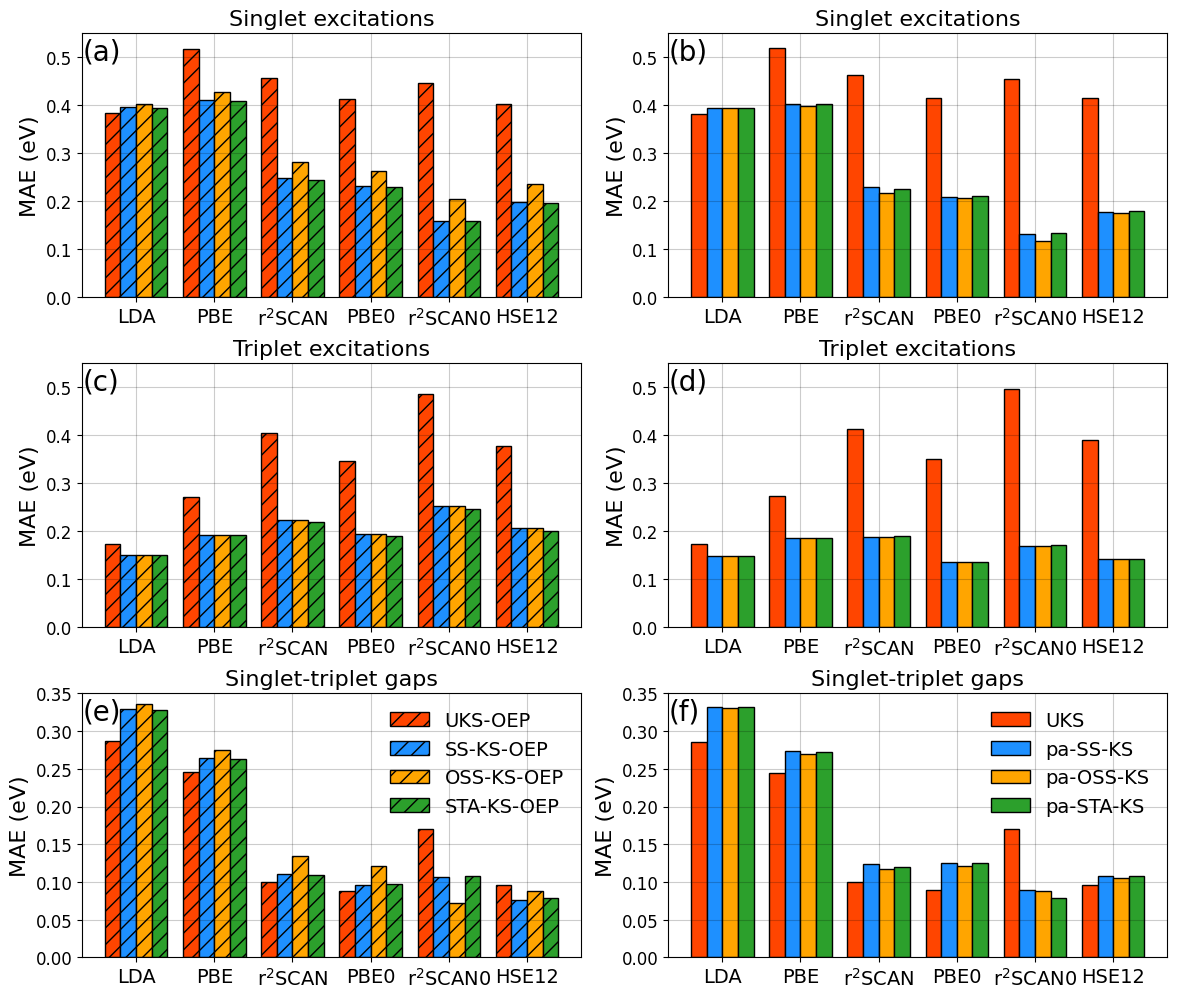

In [17]:
XC = ["LDA", "PBE", "r2SCAN", "PBE0", "r2SCAN0", "HSE12"]
XC2name = {"LDA": "LDA", "PBE": "PBE", "r2SCAN": "r$^2$SCAN", "PBE0": "PBE0", "r2SCAN0": "r$^2$SCAN0", "HSE12": "HSE12"}

df_s = pd.read_csv("csv/MAEs_QUEST1_lowest_S.csv", index_col=0)
df_t = pd.read_csv("csv/MAEs_QUEST1_lowest_T.csv", index_col=0)
df_st = pd.read_csv("csv/MAEs_QUEST1_lowest_ST.csv", index_col=0)

x = np.arange(len(df_s))

fig, axs = plt.subplots(3, 2, figsize=(14.0, 12.0))
plt.subplots_adjust(hspace=0.25, wspace=0.175)

axs[0, 0].set_title("Singlet excitations")
axs[0, 0].bar(
    x - 0.3, df_s.values[:, :4].T[0][:], color="orangered", edgecolor="black", hatch="//", width=0.2, label="UKS-OEP"
)
axs[0, 0].bar(
    x - 0.1, df_s.values[:, :4].T[1][:], color="dodgerblue", edgecolor="black", hatch="//", width=0.2, label="SS-KS-OEP"
)
axs[0, 0].bar(
    x + 0.1, df_s.values[:, :4].T[2][:], color="orange", edgecolor="black", hatch="//", width=0.2, label="OSS-KS-OEP"
)
axs[0, 0].bar(
    x + 0.3, df_s.values[:, :4].T[3][:], color="tab:green", edgecolor="black", hatch="//", width=0.2, label="STA-KS-OEP"
)

axs[1, 0].set_title("Triplet excitations")
axs[1, 0].bar(
    x - 0.3, df_t.values[:, :4].T[0][:], color="orangered", edgecolor="black", hatch="//", width=0.2, label="UKS-OEP"
)
axs[1, 0].bar(
    x - 0.1, df_t.values[:, :4].T[1][:], color="dodgerblue", edgecolor="black", hatch="//", width=0.2, label="SS-KS-OEP"
)
axs[1, 0].bar(
    x + 0.1, df_t.values[:, :4].T[2][:], color="orange", edgecolor="black", hatch="//", width=0.2, label="OSS-KS-OEP"
)
axs[1, 0].bar(
    x + 0.3, df_t.values[:, :4].T[3][:], color="tab:green", edgecolor="black", hatch="//", width=0.2, label="STA-KS-OEP"
)

axs[2, 0].set_title("Singlet-triplet gaps")
axs[2, 0].bar(
    x - 0.3, df_st.values[:, :4].T[0][:], color="orangered", edgecolor="black", hatch="//", width=0.2, label="UKS-OEP"
)
axs[2, 0].bar(
    x - 0.1,
    df_st.values[:, :4].T[1][:],
    color="dodgerblue",
    edgecolor="black",
    hatch="//",
    width=0.2,
    label="SS-KS-OEP",
)
axs[2, 0].bar(
    x + 0.1, df_st.values[:, :4].T[2][:], color="orange", edgecolor="black", hatch="//", width=0.2, label="OSS-KS-OEP"
)
axs[2, 0].bar(
    x + 0.3,
    df_st.values[:, :4].T[3][:],
    color="tab:green",
    edgecolor="black",
    hatch="//",
    width=0.2,
    label="STA-KS-OEP",
)

axs[2, 0].legend(frameon=False)

axs[0, 1].set_title("Singlet excitations")
axs[0, 1].bar(x - 0.3, df_s.values[:, 4:].T[0][:], color="orangered", edgecolor="black", width=0.2, label="UKS")
axs[0, 1].bar(x - 0.1, df_s.values[:, 4:].T[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="pa-SS-KS")
axs[0, 1].bar(x + 0.1, df_s.values[:, 4:].T[2][:], color="orange", edgecolor="black", width=0.2, label="pa-OSS-KS")
axs[0, 1].bar(x + 0.3, df_s.values[:, 4:].T[3][:], color="tab:green", edgecolor="black", width=0.2, label="pa-STA-KS")

axs[1, 1].set_title("Triplet excitations")
axs[1, 1].bar(x - 0.3, df_t.values[:, 4:].T[0][:], color="orangered", edgecolor="black", width=0.2, label="UKS")
axs[1, 1].bar(x - 0.1, df_t.values[:, 4:].T[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="pa-SS-KS")
axs[1, 1].bar(x + 0.1, df_t.values[:, 4:].T[2][:], color="orange", edgecolor="black", width=0.2, label="pa-OSS-KS")
axs[1, 1].bar(x + 0.3, df_t.values[:, 4:].T[3][:], color="tab:green", edgecolor="black", width=0.2, label="pa-STA-KS")

axs[2, 1].set_title("Singlet-triplet gaps")
axs[2, 1].bar(x - 0.3, df_st.values[:, 4:].T[0][:], color="orangered", edgecolor="black", width=0.2, label="UKS")
axs[2, 1].bar(x - 0.1, df_st.values[:, 4:].T[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="pa-SS-KS")
axs[2, 1].bar(x + 0.1, df_st.values[:, 4:].T[2][:], color="orange", edgecolor="black", width=0.2, label="pa-OSS-KS")
axs[2, 1].bar(x + 0.3, df_st.values[:, 4:].T[3][:], color="tab:green", edgecolor="black", width=0.2, label="pa-STA-KS")

axs[2, 1].legend(frameon=False)

for ax in axs.flat:
    ax.set_xticks(range(len(XC)))
    ax.set_xticklabels(map(lambda x: XC2name[x], XC), fontsize=14)
    ax.set_ylabel("MAE (eV)")
    ax.grid(alpha=0.2, color="black")

axs[0, 0].set_ylim(0, 0.55)
axs[1, 0].set_ylim(0, 0.55)
axs[2, 0].set_ylim(0, 0.35)
axs[0, 1].set_ylim(0, 0.55)
axs[1, 1].set_ylim(0, 0.55)
axs[2, 1].set_ylim(0, 0.35)

plt.text(0.0, 0.90, "(a)", fontsize=20, weight="medium", transform=axs[0, 0].transAxes)
plt.text(0.0, 0.90, "(b)", fontsize=20, weight="medium", transform=axs[0, 1].transAxes)
plt.text(0.0, 0.90, "(c)", fontsize=20, weight="medium", transform=axs[1, 0].transAxes)
plt.text(0.0, 0.90, "(d)", fontsize=20, weight="medium", transform=axs[1, 1].transAxes)
plt.text(0.0, 0.90, "(e)", fontsize=20, weight="medium", transform=axs[2, 0].transAxes)
plt.text(0.0, 0.90, "(f)", fontsize=20, weight="medium", transform=axs[2, 1].transAxes)

plt.savefig("MAEs_QUEST1_lowest.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

plt.show()

### 2.2 Scatter plot for lowest excitations of QUEST1

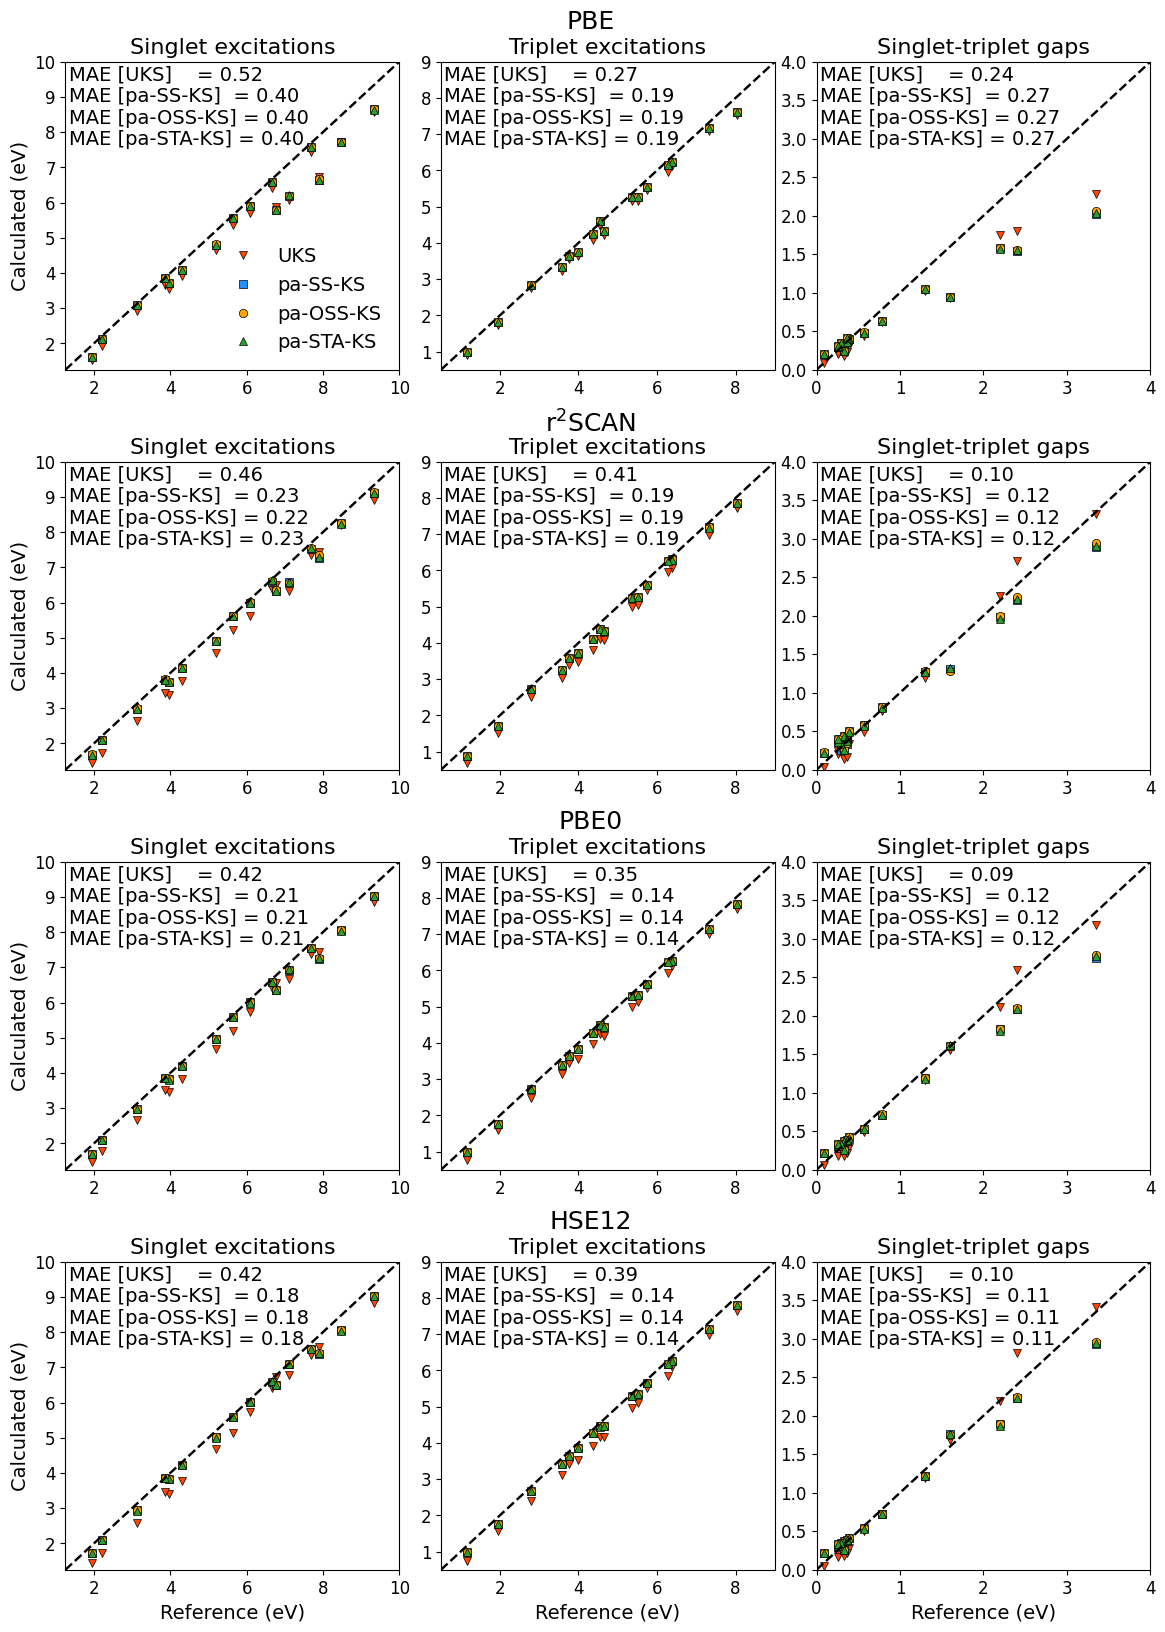

In [18]:
def fline(x):
    return x


def make_figure(s, s_sa, s_oss, s_sta, s_ref, t, t_sa, t_oss, t_sta, t_ref, title, axs):

    axs[0].set_title("Singlet excitations")
    axs[0].plot(s_ref, s, "v", color="orangered", markeredgecolor="black", markeredgewidth=0.5, label="UKS")
    axs[0].plot(s_ref, s_sa, "s", color="dodgerblue", markeredgecolor="black", markeredgewidth=0.5, label="pa-SS-KS")
    axs[0].plot(s_ref, s_oss, "o", color="orange", markeredgecolor="black", markeredgewidth=0.5, label="pa-OSS-KS")
    axs[0].plot(s_ref, s_sta, "^", color="tab:green", markeredgecolor="black", markeredgewidth=0.5, label="pa-STA-KS")
    x = np.linspace(1.25, 10.0)
    axs[0].plot(x, fline(x), "k--")
    axs[0].set_xlim(1.25, 10)
    axs[0].set_ylim(1.25, 10)

    mae = np.mean(np.abs(s_ref - s))
    plt.text(0.01, 0.94, f"MAE [UKS]    ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[0].transAxes)
    mae = np.mean(np.abs(s_ref - s_sa))
    plt.text(0.01, 0.87, f"MAE [pa-SS-KS]  ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[0].transAxes)
    mae = np.mean(np.abs(s_ref - s_oss))
    plt.text(0.01, 0.80, f"MAE [pa-OSS-KS] ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[0].transAxes)
    mae = np.mean(np.abs(s_ref - s_sta))
    plt.text(0.01, 0.73, f"MAE [pa-STA-KS] ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[0].transAxes)

    axs[1].set_title("Triplet excitations")
    axs[1].plot(t_ref, t, "v", color="orangered", markeredgecolor="black", markeredgewidth=0.5, label="UKS")
    axs[1].plot(t_ref, t_sa, "s", color="dodgerblue", markeredgecolor="black", markeredgewidth=0.5, label="pa-SS-KS")
    axs[1].plot(t_ref, t_oss, "o", color="orange", markeredgecolor="black", markeredgewidth=0.5, label="pa-OSS-KS")
    axs[1].plot(t_ref, t_sta, "^", color="tab:green", markeredgecolor="black", markeredgewidth=0.5, label="pa-STA-KS")
    x = np.linspace(0.5, 9.0)
    axs[1].plot(x, fline(x), "k--")
    axs[1].set_xlim(0.5, 9)
    axs[1].set_ylim(0.5, 9)

    mae = np.mean(np.abs(t_ref - t))
    plt.text(0.01, 0.94, f"MAE [UKS]    ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[1].transAxes)
    mae = np.mean(np.abs(t_ref - t_sa))
    plt.text(0.01, 0.87, f"MAE [pa-SS-KS]  ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[1].transAxes)
    mae = np.mean(np.abs(t_ref - t_oss))
    plt.text(0.01, 0.80, f"MAE [pa-OSS-KS] ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[1].transAxes)
    mae = np.mean(np.abs(t_ref - t_sta))
    plt.text(0.01, 0.73, f"MAE [pa-STA-KS] ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[1].transAxes)

    axs[2].set_title("Singlet-triplet gaps")
    axs[2].plot(s_ref - t_ref, s - t, "v", color="orangered", markeredgecolor="black", markeredgewidth=0.5, label="UKS")
    axs[2].plot(
        s_ref - t_ref,
        s_sa - t_sa,
        "s",
        color="dodgerblue",
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="pa-SS-KS",
    )
    axs[2].plot(
        s_ref - t_ref,
        s_oss - t_oss,
        "o",
        color="orange",
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="pa-OSS-KS",
    )
    axs[2].plot(
        s_ref - t_ref,
        s_sta - t_sta,
        "^",
        color="tab:green",
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="pa-STA-KS",
    )
    x = np.linspace(0.0, 4.0)
    axs[2].plot(x, fline(x), "k--")
    axs[2].set_xlim(0, 4)
    axs[2].set_ylim(0, 4)

    mae = np.mean(np.abs(s_ref - t_ref - s + t))
    plt.text(0.01, 0.94, f"MAE [UKS]    ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[2].transAxes)
    mae = np.mean(np.abs(s_ref - t_ref - s_sa + t_sa))
    plt.text(0.01, 0.87, f"MAE [pa-SS-KS]  ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[2].transAxes)
    mae = np.mean(np.abs(s_ref - t_ref - s_oss + t_oss))
    plt.text(0.01, 0.80, f"MAE [pa-OSS-KS] ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[2].transAxes)
    mae = np.mean(np.abs(s_ref - t_ref - s_sta + t_sta))
    plt.text(0.01, 0.73, f"MAE [pa-STA-KS] ={mae:5.2f}", fontsize=14, weight="medium", transform=axs[2].transAxes)


XC4PLOT = ["PBE", "r2SCAN", "PBE0", "HSE12"]

fig = plt.figure(figsize=(14, 16.0))
plt.subplots_adjust(wspace=0.125)

subfigs = fig.subfigures(nrows=4, ncols=1)
for row, subfig in enumerate(subfigs):
    subfig.suptitle(XC2name[XC4PLOT[row]], fontsize=18, y=1.01)

    axs = subfig.subplots(nrows=1, ncols=3)
    df = pd.read_csv(f"csv/QUEST1_lowest_{XC4PLOT[row]}.csv", index_col=0)
    make_figure(
        df["UKS S"],
        df["pa-SS-KS S"],
        df["pa-OSS-KS S"],
        df["pa-STA-KS S"],
        df["TBE S"],
        df["UKS T"],
        df["pa-SS-KS T"],
        df["pa-OSS-KS T"],
        df["pa-STA-KS T"],
        df["TBE T"],
        XC2name[XC4PLOT[row]],
        axs,
    )

    if row == 0:
        axs[0].legend(frameon=False, loc=4, fontsize=14)
    axs[0].set_ylabel("Calculated (eV)", fontsize=14)
    if row == 3:
        axs[0].set_xlabel("Reference (eV)", fontsize=14)
        axs[1].set_xlabel("Reference (eV)", fontsize=14)
        axs[2].set_xlabel("Reference (eV)", fontsize=14)

plt.savefig("QUEST1_lowest_scatter.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

### 2.3 MAEs for higher-lying excitations of QUEST1

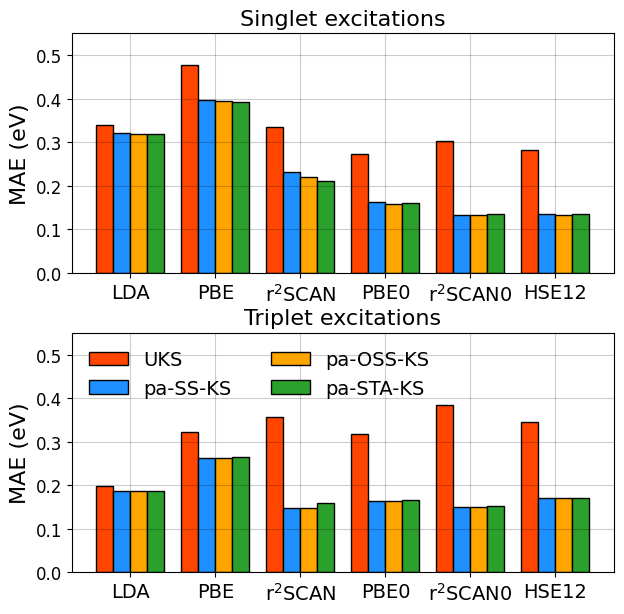

In [19]:
df_s = pd.read_csv("csv/MAEs_QUEST1_higher_S.csv", index_col=0)
df_t = pd.read_csv("csv/MAEs_QUEST1_higher_T.csv", index_col=0)

fig, axs = plt.subplots(2, 1, figsize=(7.0, 7.0))
plt.subplots_adjust(hspace=0.25)

x = np.arange(len(XC))

axs[0].bar(x - 0.3, df_s.values.T[0][:], color="orangered", edgecolor="black", width=0.2, label="UKS")
axs[0].bar(x - 0.1, df_s.values.T[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="pa-SS-KS")
axs[0].bar(x + 0.1, df_s.values.T[2][:], color="orange", edgecolor="black", width=0.2, label="pa-OSS-KS")
axs[0].bar(x + 0.3, df_s.values.T[3][:], color="tab:green", edgecolor="black", width=0.2, label="pa-STA-KS")
axs[0].set_title("Singlet excitations")

axs[1].bar(x - 0.3, df_t.values.T[0][:], color="orangered", edgecolor="black", width=0.2, label="UKS")
axs[1].bar(x - 0.1, df_t.values.T[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="pa-SS-KS")
axs[1].bar(x + 0.1, df_t.values.T[2][:], color="orange", edgecolor="black", width=0.2, label="pa-OSS-KS")
axs[1].bar(x + 0.3, df_t.values.T[3][:], color="tab:green", edgecolor="black", width=0.2, label="pa-STA-KS")
axs[1].set_title("Triplet excitations")

axs[1].legend(frameon=False, loc=2, ncols=2)

for ax in axs.flat:
    ax.set_xticks(range(len(XC)))

    ax.set_xticklabels(map(lambda x: XC2name[x], XC), fontsize=14)
    ax.set_ylabel("MAE (eV)")
    ax.set_ylim(0, 0.55)
    ax.grid(alpha=0.2, color="black")

plt.savefig("MAEs_QUEST1_higher.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

plt.show()

### 2.4 MAEs for QUEST6

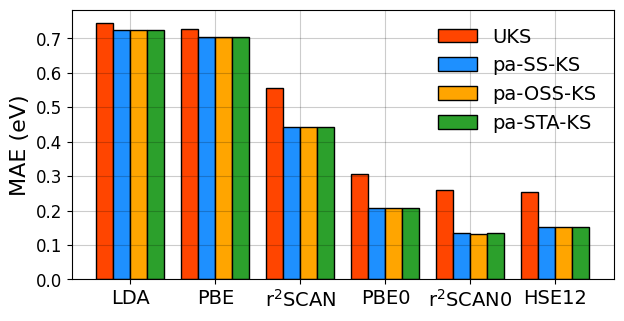

In [20]:
df = pd.read_csv("csv/MAEs_QUEST6.csv", index_col=0)

fig, ax = plt.subplots(1, 1, figsize=(7.0, 3.5))
plt.subplots_adjust(hspace=0.25)

x = np.arange(len(XC))

ax.bar(x - 0.3, df.values.T[0][:], color="orangered", edgecolor="black", width=0.2, label="UKS")
ax.bar(x - 0.1, df.values.T[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="pa-SS-KS")
ax.bar(x + 0.1, df.values.T[2][:], color="orange", edgecolor="black", width=0.2, label="pa-OSS-KS")
ax.bar(x + 0.3, df.values.T[3][:], color="tab:green", edgecolor="black", width=0.2, label="pa-STA-KS")


ax.legend(frameon=False)
ax.set_xticks(range(len(XC)))
ax.set_xticklabels(map(lambda x: XC2name[x], XC), fontsize=14)
ax.set_ylabel("MAE (eV)")
ax.grid(alpha=0.2, color="black")

plt.savefig("MAEs_QUEST6.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

plt.show()

### 2.5 pa-STA-KS vs TDDFT

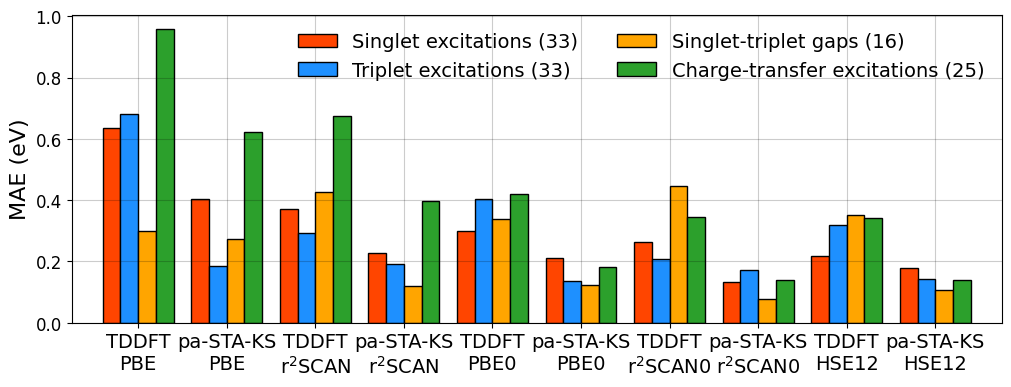

In [21]:
df_quest1_tddft = pd.read_csv("csv/QUEST1-TDDFT.csv")
df_quest1_tddft_lowest = df_quest1_tddft.sort_values(by=["TBE S"]).drop_duplicates(subset=["Molecule"], keep="first")

df_quest6_tddft = pd.read_csv("csv/QUEST6-TDDFT.csv", delimiter=";")
df_quest6_tddft.Molecule = df_quest6_tddft.Molecule + " " + df_quest6_tddft.State
df_quest6_tddft = df_quest6_tddft.drop(df_quest6_tddft[df_quest6_tddft.Molecule == "N-Phenylpyrrole B2"].index)
df_quest6_tddft = df_quest6_tddft.drop(df_quest6_tddft[df_quest6_tddft.Molecule == "Twisted DMABN A2"].index)
df_quest6_tddft = df_quest6_tddft.reset_index(drop=True)

df_maes_st = pd.read_csv("csv/MAEs_QUEST1_lowest_ST.csv", index_col=0)

df_maes_s_1 = pd.read_csv("csv/MAEs_QUEST1_lowest_S.csv", index_col=0)
df_maes_s_2 = pd.read_csv("csv/MAEs_QUEST1_lowest_S.csv", index_col=0)
df_maes_s = df_maes_s_1 * 16 / 33 + df_maes_s_2 * 17 / 33

df_maes_t_1 = pd.read_csv("csv/MAEs_QUEST1_lowest_T.csv", index_col=0)
df_maes_t_2 = pd.read_csv("csv/MAEs_QUEST1_lowest_T.csv", index_col=0)
df_maes_t = df_maes_t_1 * 16 / 33 + df_maes_t_2 * 17 / 33

df_maes_ct = pd.read_csv("csv/MAEs_QUEST6_only_STA.csv", index_col=0)

maes_s, maes_t, maes_st, maes_ct = [], [], [], []

for xc in ["PBE", "r2SCAN", "PBE0", "r2SCAN0", "HSE12"]:
    maes_s.append(np.mean(np.abs(df_quest1_tddft[f"{xc} S"] - df_quest1_tddft["TBE S"])))
    maes_t.append(np.mean(np.abs(df_quest1_tddft[f"{xc} T"] - df_quest1_tddft["TBE T"])))
    maes_st.append(
        np.mean(
            np.abs(
                df_quest1_tddft_lowest[f"{xc} S"]
                - df_quest1_tddft_lowest["TBE S"]
                - df_quest1_tddft_lowest[f"{xc} T"]
                + df_quest1_tddft_lowest["TBE T"]
            )
        )
    )
    maes_ct.append(np.mean(np.abs(df_quest6_tddft[f"{xc} S"] - df_quest6_tddft["TBE S"])))

    maes_st.append(df_maes_st["pa-STA-KS"][xc.replace("r2", "r$^2$")])
    maes_s.append(df_maes_s["pa-STA-KS"][xc.replace("r2", "r$^2$")])
    maes_t.append(df_maes_t["pa-STA-KS"][xc.replace("r2", "r$^2$")])
    maes_ct.append(df_maes_ct["pa-STA-KS"][xc.replace("r2", "r$^2$")])

maes_s = np.array(maes_s).T
maes_t = np.array(maes_t).T
maes_st = np.array(maes_st).T
maes_ct = np.array(maes_ct).T
maes = np.vstack((maes_s, maes_t, maes_st, maes_ct))

labels = [
    "TDDFT\nPBE",
    "pa-STA-KS\nPBE",
    "TDDFT\nr$^2$SCAN",
    "pa-STA-KS\nr$^2$SCAN",
    "TDDFT\nPBE0",
    "pa-STA-KS\nPBE0",
    "TDDFT\nr$^2$SCAN0",
    "pa-STA-KS\nr$^2$SCAN0",
    "TDDFT\nHSE12",
    "pa-STA-KS\nHSE12",
]

fig, ax = plt.subplots(1, 1, figsize=(12, 4.0))
plt.subplots_adjust(hspace=0.25)

x = np.arange(maes_s.shape[0])

ax.bar(x - 0.3, maes[0][:], color="orangered", edgecolor="black", width=0.2, label="Singlet excitations (33)")
ax.bar(x - 0.1, maes[1][:], color="dodgerblue", edgecolor="black", width=0.2, label="Triplet excitations (33)")
ax.bar(x + 0.1, maes[2][:], color="orange", edgecolor="black", width=0.2, label="Singlet-triplet gaps (16)")
ax.bar(x + 0.3, maes[3][:], color="tab:green", edgecolor="black", width=0.2, label="Charge-transfer excitations (25)")

ax.legend(frameon=False, ncol=2)
ax.set_xticks(np.arange(maes_s.shape[0]))
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel("MAE (eV)")
ax.set_xlim(-0.75, 9.75)
ax.grid(alpha=0.2, color="black")

plt.savefig("Compare_with_TDDFT.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

plt.show()